# **Training Notebook**
### 🎯 **Gesture Recognition Application Using Feature Extraction - Assignment #1**

> Ilka BRETSCHNEIDER <br> Romain NOBLET


*Università degli Studi di Trento - 2026*

**Setup environment**

In [2]:
# Setup environment
!apt-get -qq install xxd
!pip install pandas numpy matplotlib
!pip install tensorflow

**Load data and normalization**

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

print(f"TensorFlow version = {tf.__version__}\n")

# Set a fixed random seed value, for reproducibility, this will allow us to get
# the same random numbers each time the notebook is run
SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

# the list of gestures that data is available for
GESTURES = [
    "punch",
    "flex",
]

SAMPLES_PER_GESTURE = 119

NUM_GESTURES = len(GESTURES)

# create a one-hot encoded matrix that is used in the output
ONE_HOT_ENCODED_GESTURES = np.eye(NUM_GESTURES)

inputs = []
outputs = []

def rms(x):
    return np.sqrt(np.mean(np.square(x)))

def psd_energy(x):
    fft = np.fft.rfft(x)
    psd = np.abs(fft)**2
    return np.sum(psd)

# read each csv file and push an input and output
for gesture_index in range(NUM_GESTURES):
  gesture = GESTURES[gesture_index]
  print(f"Processing index {gesture_index} for gesture '{gesture}'.")

  output = ONE_HOT_ENCODED_GESTURES[gesture_index]

  df = pd.read_csv("/content/" + gesture + ".csv")

  # calculate the number of gesture recordings in the file
  num_recordings = int(df.shape[0] / SAMPLES_PER_GESTURE)

  print(f"\tThere are {num_recordings} recordings of the {gesture} gesture.")


  for i in range(num_recordings):

    ax, ay, az = [], [], []
    gx, gy, gz = [], [], []

    # collect the 119 samples
    for j in range(SAMPLES_PER_GESTURE):
        index = i * SAMPLES_PER_GESTURE + j

        ax.append(df['aX'][index])
        ay.append(df['aY'][index])
        az.append(df['aZ'][index])

        gx.append(df['gX'][index])
        gy.append(df['gY'][index])
        gz.append(df['gZ'][index])

    # compute features
    tensor = [
        np.mean(ax), np.std(ax), rms(ax), np.min(ax), np.max(ax), psd_energy(ax),
        np.mean(ay), np.std(ay), rms(ay), np.min(ay), np.max(ay), psd_energy(ay),
        np.mean(az), np.std(az), rms(az), np.min(az), np.max(az), psd_energy(az),

        np.mean(gx), np.std(gx), rms(gx), np.min(gx), np.max(gx), psd_energy(gx),
        np.mean(gy), np.std(gy), rms(gy), np.min(gy), np.max(gy), psd_energy(gy),
        np.mean(gz), np.std(gz), rms(gz), np.min(gz), np.max(gz), psd_energy(gz),
    ]

    # normalize feature vector
    tensor = np.array(tensor)
    tensor = (tensor - np.min(tensor)) / (np.max(tensor) - np.min(tensor))

    inputs.append(tensor)
    outputs.append(output)

# convert the list to numpy array
inputs = np.array(inputs)
outputs = np.array(outputs)

print("Data set parsing and preparation complete.")

TensorFlow version = 2.19.0

Processing index 0 for gesture 'punch'.
	There are 13 recordings of the punch gesture.
Processing index 1 for gesture 'flex'.
	There are 16 recordings of the flex gesture.
Data set parsing and preparation complete.


**Randomize and split the input and output pairs for training**

In [4]:
# Randomize the order of the inputs, so they can be evenly distributed for training, testing, and validation
# https://stackoverflow.com/a/37710486/2020087
num_inputs = len(inputs)
randomize = np.arange(num_inputs)
np.random.shuffle(randomize)

# Swap the consecutive indexes (0, 1, 2, etc) with the randomized indexes
inputs = inputs[randomize]
outputs = outputs[randomize]

# Split the recordings (group of samples) into three sets: training, testing and validation
TRAIN_SPLIT = int(0.6 * num_inputs)
TEST_SPLIT = int(0.2 * num_inputs + TRAIN_SPLIT)

inputs_train, inputs_test, inputs_validate = np.split(inputs, [TRAIN_SPLIT, TEST_SPLIT])
outputs_train, outputs_test, outputs_validate = np.split(outputs, [TRAIN_SPLIT, TEST_SPLIT])

print("Data set randomization and splitting complete.")

Data set randomization and splitting complete.


**Training a NN**

In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(inputs.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(NUM_GESTURES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    inputs_train,
    outputs_train,
    epochs=200,
    batch_size=8,
    validation_data=(inputs_validate, outputs_validate)
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.5478 - loss: 0.6972 - val_accuracy: 0.2857 - val_loss: 0.7227
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5478 - loss: 0.6721 - val_accuracy: 0.2857 - val_loss: 0.7071
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5478 - loss: 0.6578 - val_accuracy: 0.2857 - val_loss: 0.6906
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5478 - loss: 0.6451 - val_accuracy: 0.2857 - val_loss: 0.6766
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5478 - loss: 0.6332 - val_accuracy: 0.2857 - val_loss: 0.6623
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6673 - loss: 0.6196 - val_accuracy: 1.0000 - val_loss: 0.6461
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.6060 - val_accuracy: 1.0000 - val_loss: 0.6300
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.5914 - val_accuracy: 1.0000 - val_loss

**Model evaluation using accuracy and a confusion matrix**

In [13]:
test_loss, test_acc = model.evaluate(inputs_test, outputs_test)
print("Test accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 3.4492e-04
Test accuracy: 1.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


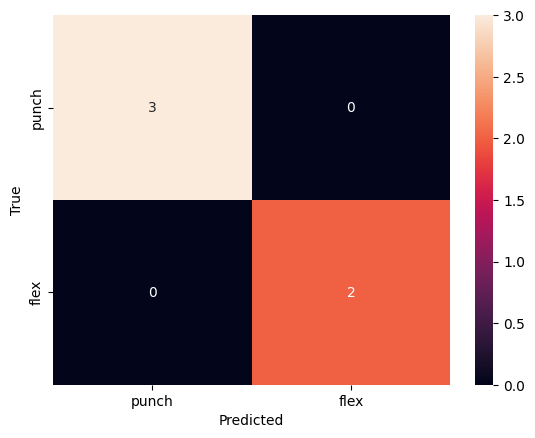

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = model.predict(inputs_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(outputs_test, axis=1)

cm = confusion_matrix(true_classes, predicted_classes)

sns.heatmap(cm, annot=True, fmt="d", xticklabels=GESTURES, yticklabels=GESTURES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

**The trained model parameters (weights and biases) are exported for deployment on Arduino.**

In [17]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Save the quantized model to disk
with open("/content/gesture_model_quant.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpyo4f62ku'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 36), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  138306533218768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138306533215312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138306533218384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138306533218960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138306533218192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138306533216656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138306533219536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138306533215696: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [19]:
!echo "const unsigned char model[] = {" > /content/model.h
!cat gesture_model_quant.tflite | xxd -i -c 12 | sed '1d;$d' >> /content/model.h
!echo "};" >> /content/model.h

import os
model_h_size = os.path.getsize("model.h")
print(f"Header file, model.h, is {model_h_size:,} bytes.")
print("\nOpen the side panel (refresh if needed). Double click model.h to download the file.")

Header file, model.h, is 66,043 bytes.

Open the side panel (refresh if needed). Double click model.h to download the file.
